In [13]:
import pandas as pd 

# Load One Hot Encoded data for Random Forest 
X_train_rf = pd.read_csv('../data/processed/X_train_rf.csv')
X_test_rf = pd.read_csv('../data/processed/X_test_rf.csv')

# Load Native Categorical data for XGBoost and LightGBM
X_train_native = pd.read_pickle('../data/processed/X_train_native.pkl')
X_test_native = pd.read_pickle('../data/processed/X_test_native.pkl')

# Load Target variable and convert to 1D series 
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Print Shapes 
print("--- Random Forest Data ---")
print(f"X_train_rf shape: {X_train_rf.shape}")
print(f"X_test_rf shape: {X_test_rf.shape}")
print("\n--- Native Categorical Data ---")
print(f"X_train_native shape: {X_train_native.shape}")
print(f"X_test_native shape:  {X_test_native.shape}")
print("\n--- Target Variables ---")
print(f"y_train shape:        {y_train.shape}")
print(f"y_test shape:         {y_test.shape}")

--- Random Forest Data ---
X_train_rf shape: (2904, 158)
X_test_rf shape: (726, 158)

--- Native Categorical Data ---
X_train_native shape: (2904, 30)
X_test_native shape:  (726, 30)

--- Target Variables ---
y_train shape:        (2904,)
y_test shape:         (726,)


Random Forest

Baseline Random Forest

In [2]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Create Random Forest with balanced class weights and fix seeds
rf_default = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

# Run 5 Fold cross validation on the one hot encoded training data.
cv_scores_default = cross_val_score(
    rf_default,
    X_train_rf,
    y_train,
    cv=5,
    scoring='f1'
)
# Calculate and print the mean F1 score
mean_f1_default = np.mean(cv_scores_default)

print(f"Random Forest (Default) 5 Fold CV F1 Score: {mean_f1_default:.4f}")

Random Forest (Default) 5 Fold CV F1 Score: 0.8362


In [3]:
# print all the default parameters of the baseline model 
current_parameters = rf_default.get_params()

print("Default Random Forest Parameters:")
for param, value in current_parameters.items():
    print(f" {param}: {value}")

Default Random Forest Parameters:
 bootstrap: True
 ccp_alpha: 0.0
 class_weight: balanced
 criterion: gini
 max_depth: None
 max_features: sqrt
 max_leaf_nodes: None
 max_samples: None
 min_impurity_decrease: 0.0
 min_samples_leaf: 1
 min_samples_split: 2
 min_weight_fraction_leaf: 0.0
 monotonic_cst: None
 n_estimators: 100
 n_jobs: None
 oob_score: False
 random_state: 42
 verbose: 0
 warm_start: False


Tunning with OPTUNA

In [ ]:
import time 
import optuna
import numpy as np 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function for Optuna
def objective_rf(trial):
    rf_params ={
            # Hyperparameters
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        
        # Baseline constraints
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1
    }

    # Initialise and evaluate the model
    model = RandomForestClassifier(**rf_params)
    scores = cross_val_score(
        model,
        X_train_rf,
        y_train,
        cv=5,
        scoring='f1'
    )
    return np.mean(scores)

# Suppress Optuna's verbose trial logs
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Create and run study
sampler = optuna.samplers.TPESampler(seed=42)
study_rf = optuna.create_study(
    direction='maximize',
    sampler=sampler
)
print("Starting Optuna tunning")

# Initialise the timer
start_time = time.time()

# Execute the 100 trails
study_rf.optimize(objective_rf, n_trials=100)

# Stop the timer and calculate duration
end_time = time.time()
execution_time = end_time - start_time
minutes = int(execution_time // 60)
seconds = int(execution_time % 60)

print(f"Tuning Completed in {minutes} minutes and {seconds} seconds.\n")
print(f"Best Random Forest F1 Score (Dropout): {study_rf.best_value:.4f}")
print("Best Parameters:")
for key, value in study_rf.best_params.items():
    print(f"  {key}: {value}")

Starting Optuna tunning
Tuning Completed in 6 minutes and 15 seconds.

Best Random Forest F1 Score (Dropout): 0.8412
Best Parameters:
  n_estimators: 873
  max_depth: 7
  min_samples_split: 12
  min_samples_leaf: 3
  max_features: None
  criterion: entropy


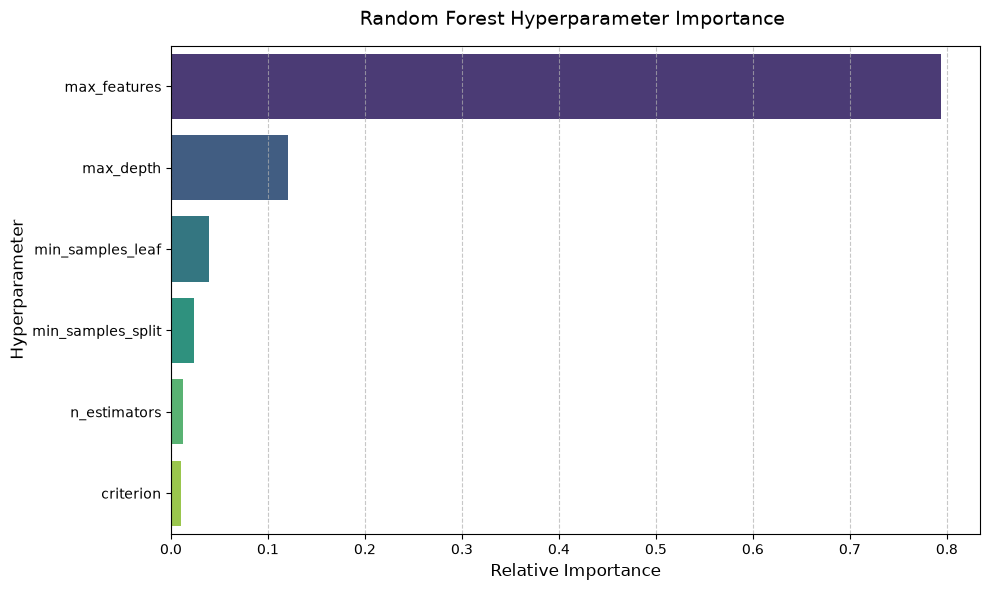

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from optuna.importance import get_param_importances

# Extract the raw numerical importance values directly from the study
importances = get_param_importances(study_rf)

# Separate the dictionary into lists for plotting
params = list(importances.keys())
scores = list(importances.values())

# Create Seaborn bar plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x=scores, 
    y=params, 
    palette='viridis',
     hue=params, 
     legend=False
     )

# Apply Title
plt.title('Random Forest Hyperparameter Importance ', fontsize=14, pad=15)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Hyperparameter', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('../outputs/figures/rf_importance_custom.png', dpi=300, bbox_inches='tight')
plt.show()

Train final RF with best parameters

In [ ]:
import joblib
from sklearn.ensemble import RandomForestClassifier

# Extract the best parameters from the completed Optuna study
best_rf_params = study_rf.best_params.copy()

# Reinject the static parameters
best_rf_params['class_weight'] = 'balanced'
best_rf_params['random_state'] = 42
best_rf_params['n_jobs'] = -1

# Print parameters being used 
print("Training Final Random Forest with parameters:")
for param, value in best_rf_params.items():
    print(f"  {param}: {value}")


# Initialise and train the model on the entire One hot encoded training dataset
final_rf = RandomForestClassifier(**best_rf_params)
final_rf.fit(X_train_rf, y_train)

# save the trained model
model_save_path = '../models/rf_final.pkl'
joblib.dump(final_rf, model_save_path)

print("Final Random Forest model trained and saved")

Training Final Random Forest with parameters:
  n_estimators: 873
  max_depth: 7
  min_samples_split: 12
  min_samples_leaf: 3
  max_features: None
  criterion: entropy
  class_weight: balanced
  random_state: 42
  n_jobs: -1
Final Random Forest model trained and saved


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Final model performance check 
final_rf_scores = cross_val_score(
    final_rf,
    X_train_rf,
    y_train,
    cv=5,
    scoring='f1'
)

print(f"Final RF Cross Validation F1: {np.mean(final_rf_scores):.4f}")

Final RF Cross Validation F1: 0.8412


XGBoost

Default XGBoost baseline

In [9]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Calculate the ratio dynamically directly from the target variable 

scale_pos = sum(y_train == 0)/ sum(y_train == 1)

# XGBoost baseline model
xgb_baseline = XGBClassifier(
    scale_pos_weight=scale_pos,
    enable_categorical=True,
    random_state=42,
    eval_metric='logloss'
)

# 5 fold cross validation on the native categorical dataset
scores_xgb_baseline = cross_val_score(
    xgb_baseline,
    X_train_native,
    y_train,
    cv=5,
    scoring='f1'
)

# Calculate the mean F1 score
mean_f1_xgb = np.mean(scores_xgb_baseline)

# default parameters
print("XGBoost Baseline Default Parameters:")
for key, value in xgb_baseline.get_params().items():
    print(f" {key}: {value}")

print(f"\nBaseline Mean CV F1 Score (Dropout): {mean_f1_xgb:.4f}")

XGBoost Baseline Default Parameters:
 objective: binary:logistic
 base_score: None
 booster: None
 callbacks: None
 colsample_bylevel: None
 colsample_bynode: None
 colsample_bytree: None
 device: None
 early_stopping_rounds: None
 enable_categorical: True
 eval_metric: logloss
 feature_types: None
 feature_weights: None
 gamma: None
 grow_policy: None
 importance_type: None
 interaction_constraints: None
 learning_rate: None
 max_bin: None
 max_cat_threshold: None
 max_cat_to_onehot: None
 max_delta_step: None
 max_depth: None
 max_leaves: None
 min_child_weight: None
 missing: nan
 monotone_constraints: None
 multi_strategy: None
 n_estimators: None
 n_jobs: None
 num_parallel_tree: None
 random_state: 42
 reg_alpha: None
 reg_lambda: None
 sampling_method: None
 scale_pos_weight: 1.554089709762533
 subsample: None
 tree_method: None
 validate_parameters: None
 verbosity: None

Baseline Mean CV F1 Score (Dropout): 0.8361


Tunning with OPTUNA

In [11]:
import time 
import optuna
import numpy as np 
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function for Optuna
def objective_xgb(trial):
    # Hyperparameters
    xgb_params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),

        # Baseline constraints
        'scale_pos_weight': scale_pos,
        'enable_categorical': True,
        'random_state': 42,
        'eval_metric': 'logloss',

        # XGB handles threading natively
        'n_jobs': None
    }

    # Initialise and evaluate the model
    model = XGBClassifier(**xgb_params)
    scores = cross_val_score(
         model,
        X_train_native,
        y_train,
        cv=5,
        scoring='f1',
        n_jobs=1
    )
    return np.mean(scores)

# Suppress Optuna's verbose trial logs
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Create and run study
sampler_xgb = optuna.samplers.TPESampler(seed=42)
study_xgb = optuna.create_study(
    direction='maximize',
    sampler=sampler_xgb
)
print("Starting XGBoost Optuna tunning")

# Initialise the timer
start_time = time.time()

# Execute the 100 trails
study_xgb.optimize(objective_xgb, n_trials=100)

# Stop the timer and calculate duration
end_time = time.time()
execution_time = end_time - start_time
minutes = int(execution_time // 60)
seconds = int(execution_time % 60)

print(f"Tuning Completed in {minutes} minutes and {seconds} seconds.\n")
print(f"Best XGBoost F1 Score (Dropout): {study_xgb.best_value:.4f}")

print("Best Parameters:")
for key, value in study_xgb.best_params.items():
    print(f"  {key}: {value}")

Starting XGBoost Optuna tunning
Tuning Completed in 2 minutes and 6 seconds.

Best XGBoost F1 Score (Dropout): 0.8539
Best Parameters:
  n_estimators: 804
  learning_rate: 0.01811869935696581
  max_depth: 4
  subsample: 0.963412299223279
  colsample_bytree: 0.9391846023223331
  reg_alpha: 0.13806072221360433
  reg_lambda: 6.203915197579071


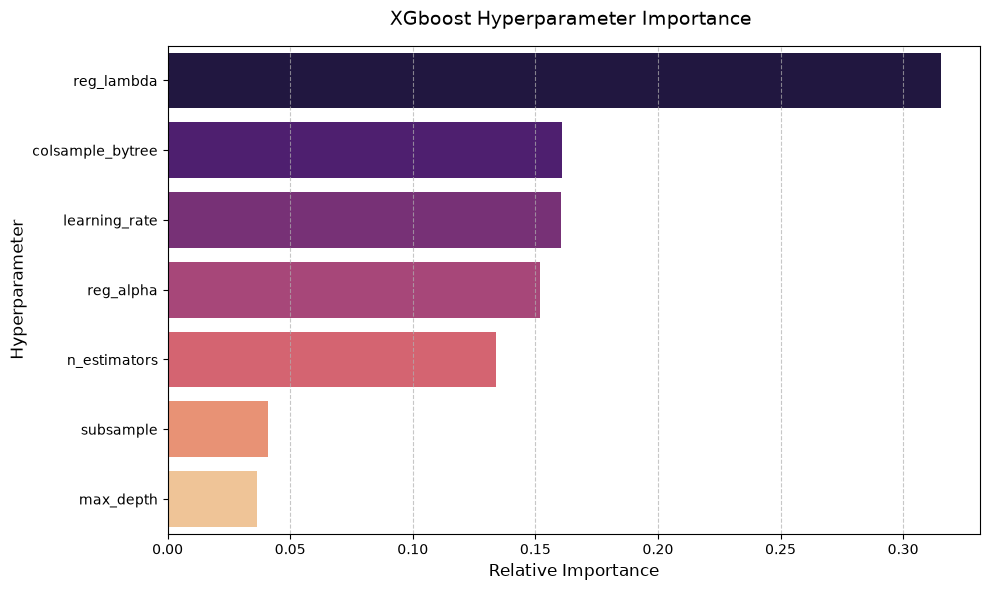

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from optuna.importance import get_param_importances

# Extract the raw numerical importance values directly from the study
importances = get_param_importances(study_xgb)

# Separate the dictionary into lists for plotting
params = list(importances.keys())
scores = list(importances.values())

# Create Seaborn bar plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x=scores, 
    y=params, 
    palette='magma',
    hue=params, 
    legend=False
)

# Apply Title
plt.title('XGboost Hyperparameter Importance ', fontsize=14, pad=15)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Hyperparameter', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('../outputs/figures/xgb_importance_custom.png', dpi=300, bbox_inches='tight')
plt.show()

Train final XGBoost with best parameters

In [14]:
import joblib
from xgboost import XGBClassifier

# Extract the best params from thencompleted study
best_xgb_params = study_xgb.best_params.copy()

# Reinject the static parameters
best_xgb_params['scale_pos_weight'] = scale_pos
best_xgb_params['enable_categorical'] = True
best_xgb_params['random_state'] = 42
best_xgb_params['eval_metric'] = 'logloss'
best_xgb_params['n_jobs'] = None

# Print the parameters being used
print("Training Final XGBoost with parameters:")
for param, value in best_xgb_params.items():
    print(f"  {param}: {value}")

# Initialise and train the model on the native categorical dataset
final_xbg = XGBClassifier(**best_xgb_params)
final_xbg.fit(X_train_native, y_train)

# save the trained model
model_save_path = '../models/xgb_final.pkl'
joblib.dump(final_xbg, model_save_path)

print("Final XGB model trained and saved")

Training Final XGBoost with parameters:
  n_estimators: 804
  learning_rate: 0.01811869935696581
  max_depth: 4
  subsample: 0.963412299223279
  colsample_bytree: 0.9391846023223331
  reg_alpha: 0.13806072221360433
  reg_lambda: 6.203915197579071
  scale_pos_weight: 1.554089709762533
  enable_categorical: True
  random_state: 42
  eval_metric: logloss
  n_jobs: None
Final XGB model trained and saved


In [15]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Final model performance check 
final_xgb_scores = cross_val_score(
    final_xbg,
    X_train_native,
    y_train,
    cv=5,
    scoring='f1'
)

print(f"Final XGBoost Cross Validation F1: {np.mean(final_xgb_scores):.4f}")

Final XGBoost Cross Validation F1: 0.8539


LightGBM

Default LightGBM baseline

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
import numpy as np


# Create LightGBM with balanced class weights and fix seeds
lgbm_baseline = LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    verbose = -1 # Silent all C++ backend warnings
)
# Run 5 Fold cross validation on the native categorical dataset
scores_lgbm_baseline = cross_val_score(
    lgbm_baseline,
    X_train_native,
    y_train,
    cv=5,
    scoring='f1'
)
# Calculate the mean F1 score
mean_f1_lgbm = np.mean(scores_lgbm_baseline)

# default parameters
print("\nLightGBM Baseline Default Parameters:")
for key, value in lgbm_baseline.get_params().items():
    print(f" {key}: {value}")

print(f"\nBaseline Mean CV F1 Score (Dropout): {mean_f1_lgbm:.4f}")


LightGBM Baseline Default Parameters:
 boosting_type: gbdt
 class_weight: balanced
 colsample_bytree: 1.0
 importance_type: split
 learning_rate: 0.1
 max_depth: -1
 min_child_samples: 20
 min_child_weight: 0.001
 min_split_gain: 0.0
 n_estimators: 100
 n_jobs: None
 num_leaves: 31
 objective: None
 random_state: 42
 reg_alpha: 0.0
 reg_lambda: 0.0
 subsample: 1.0
 subsample_for_bin: 200000
 subsample_freq: 0
 verbose: -1

Baseline Mean CV F1 Score (Dropout): 0.8429


Tunning with OPTUNA

In [17]:
import time
import optuna
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function for Optuna
def objective_lgbm(trial):
    # Hyperparameters
    lgbm_params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 10.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 10.0),
        
        # Static baseline constraints
        'class_weight': 'balanced',
        'random_state': 42,
        'verbose': -1,  # Silent all C++ backend warnings
        'n_jobs': None  # LightGBM handles its own OpenMP threading natively
    }
    # Initialise and evaluate the model
    model = LGBMClassifier(**lgbm_params)
    scores = cross_val_score(
        model,
        X_train_native,
        y_train,
        cv=5,
        scoring='f1',
        n_jobs=1 # Prevents scikit learn from flighting LightGBM for CPU cores
    )
    return np.mean(scores)

# Suppress Optuna's verbose trial logs
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Create and run study
sampler_lgbm = optuna.samplers.TPESampler(seed=42)
study_lgbm = optuna.create_study(
    direction='maximize',
    sampler=sampler_lgbm
)
print("Starting LightGBM Optuna tunning")

# Initialise the timer
start_time = time.time()

# Execute the 100 trails
study_lgbm.optimize(objective_lgbm, n_trials=100)

# Stop the timer and calculate duration
end_time = time.time()
execution_time = end_time - start_time
minutes = int(execution_time // 60)
seconds = int(execution_time % 60)

print(f"Tuning Completed in {minutes} minutes and {seconds} seconds.\n")
print(f"Best LightGBM F1 Score (Dropout): {study_lgbm.best_value:.4f}")

print("Best Parameters:")
for key, value in study_lgbm.best_params.items():
    print(f"  {key}: {value}")

Starting LightGBM Optuna tunning
Tuning Completed in 1 minutes and 8 seconds.

Best LightGBM F1 Score (Dropout): 0.8505
Best Parameters:
  n_estimators: 862
  learning_rate: 0.0648611804982706
  num_leaves: 120
  max_depth: 12
  min_child_samples: 15
  subsample: 0.9889042313820036
  colsample_bytree: 0.8339734545623698
  reg_alpha: 6.818215708795425
  reg_lambda: 9.335387446472183


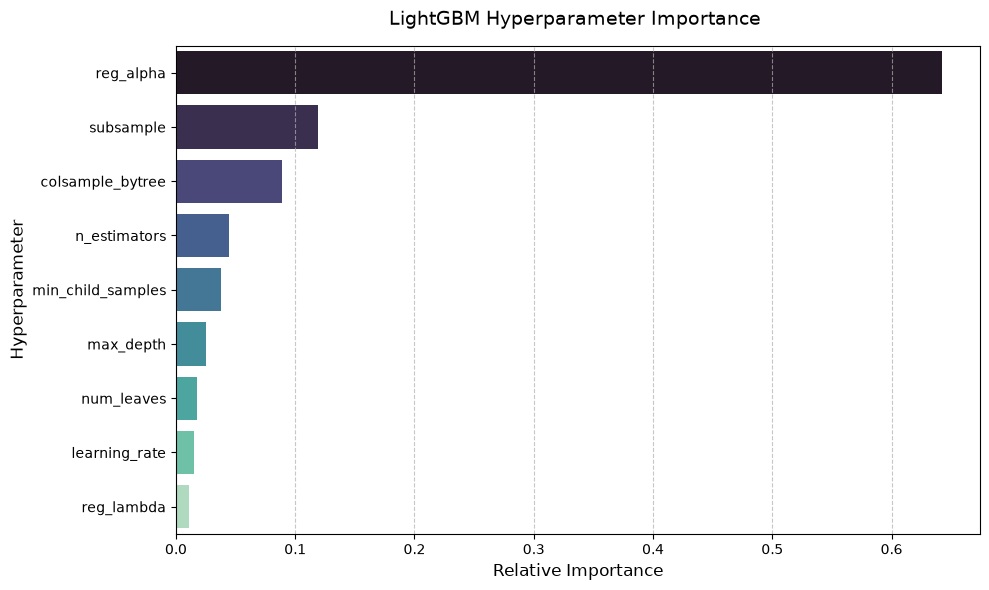

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from optuna.importance import get_param_importances

# Extract the raw numerical importance values directly from the study
importances = get_param_importances(study_lgbm)

# Separate the dictionary into lists for plotting
params = list(importances.keys())
scores = list(importances.values())

# Create Seaborn bar plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x=scores, 
    y=params, 
    palette='mako',
    hue=params, 
    legend=False
)

# Apply Title
plt.title('LightGBM Hyperparameter Importance ', fontsize=14, pad=15)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Hyperparameter', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('../outputs/figures/lgbm_importance_custom.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
import joblib
from lightgbm import LGBMClassifier

# Extract the best params from thencompleted study
best_lgbm_params = study_lgbm.best_params.copy()

# Reinject the static parameters
best_lgbm_params['class_weight'] = 'balanced'
best_lgbm_params['random_state'] = 42
best_lgbm_params['verbose'] = -1
best_lgbm_params['n_jobs'] = None

# Print the parameters being used
print("Training Final LightGBM with parameters:")
for param, value in best_lgbm_params.items():
    print(f"  {param}: {value}")

# Initialise and train the model on the native categorical dataset
final_lgbm = LGBMClassifier(**best_lgbm_params)
final_lgbm.fit(X_train_native, y_train)

# save the trained model
model_save_path = '../models/lgbm_final.pkl'
joblib.dump(final_lgbm, model_save_path)

print("Final LightGBM model trained and saved")

Training Final LightGBM with parameters:
  n_estimators: 862
  learning_rate: 0.0648611804982706
  num_leaves: 120
  max_depth: 12
  min_child_samples: 15
  subsample: 0.9889042313820036
  colsample_bytree: 0.8339734545623698
  reg_alpha: 6.818215708795425
  reg_lambda: 9.335387446472183
  class_weight: balanced
  random_state: 42
  verbose: -1
  n_jobs: None
Final LightGBM model trained and saved


In [23]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Final model performance check 
final_lgbm_scores = cross_val_score(
    final_lgbm,
    X_train_native,
    y_train,
    cv=5,
    scoring='f1'
)

print(f"Final RF Cross Validation F1: {np.mean(final_lgbm_scores):.4f}")

Final RF Cross Validation F1: 0.8505


Cross Validation Performance Summary

In [ ]:
import pandas as pd

# Define the results
summary_data = {
    'Model': ['Random Forest', 'XGBoost', 'LightGBM'],
    'Default F1': [0.8362, 0.8361, 0.8429],
    'Tuned F1': [0.8412, 0.8539, 0.8505],
    'Improvement': ['+0.0050', '+0.0178', '+0.0076']
}

# Convert to pandas DataFrame
df_summary = pd.DataFrame(summary_data)

# Set the model column as index
df_summary.set_index('Model', inplace=True)

display(df_summary)

df_summary.to_csv('../outputs/tuning_performance_summary.csv')

,Default F1,Tuned F1,Improvement
Model,,,
Random Forest,0.8362,0.8412,+0.0050
XGBoost,0.8361,0.8539,+0.0178
LightGBM,0.8429,0.8505,+0.0076


Trajectory Curves Plot

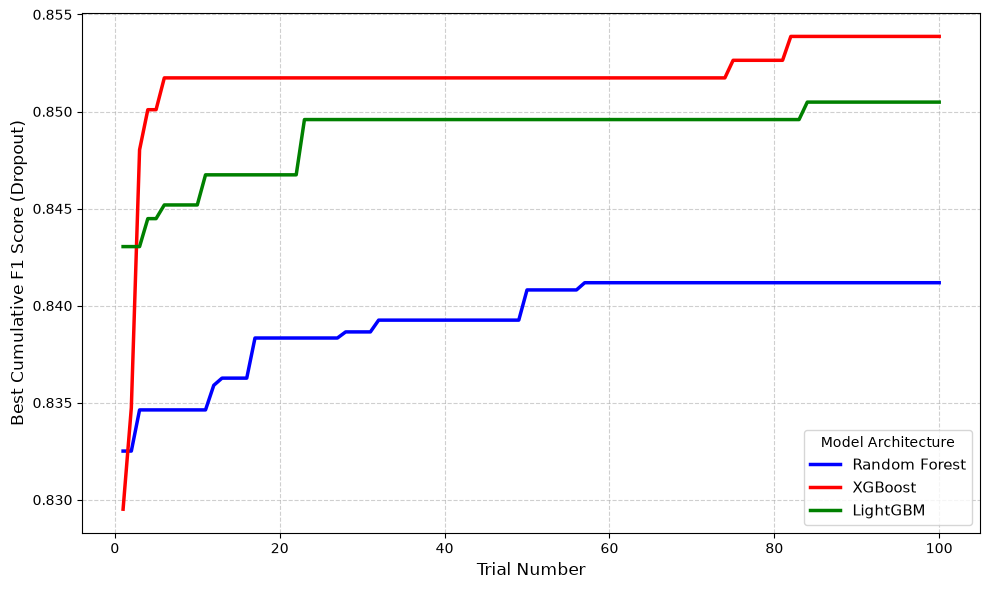

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Helper fucntion to caltulate F1 scores across all models
def get_optimization_trajectory(study):
    scores = [trial.value for trial in study.trials if trial.value is not None]
    return np.maximum.accumulate(scores)

# Extract trajectory data for all completed studies
rf_trajectory = get_optimization_trajectory(study_rf)
xgb_trajectory = get_optimization_trajectory(study_xgb)
lgbm_trajectory = get_optimization_trajectory(study_lgbm)

# Create figure
plt.figure(figsize=(10, 6))

# Plot the trajectory curves for each model
plt.plot(range(1, len(rf_trajectory) + 1), rf_trajectory, label='Random Forest', color= 'Blue', linewidth=2.5)
plt.plot(range(1, len(xgb_trajectory) + 1), xgb_trajectory, label='XGBoost', color= 'Red', linewidth=2.5)
plt.plot(range(1, len(lgbm_trajectory) + 1), lgbm_trajectory, label='LightGBM', color= 'Green', linewidth=2.5)

# Add title and labels
plt.xlabel('Trial Number', fontsize=12)
plt.ylabel('Best Cumulative F1 Score (Dropout)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Model Architecture', loc='lower right', frameon=True, fontsize=11)
plt.tight_layout()

plt.savefig('../outputs/figures/optimisation_trajectory_curves.png', dpi=300, bbox_inches='tight')
plt.show()